# 04 · Neoepitope prediction — Bobisse 302TIL (Rmd 5)

Reproduces `code_paper/5_Benchmark_neoepitopes.Rmd` on the **2026 TCRen**. The tumour TCR
**302TIL** recognises the neoepitope **`KQWLVWLFL`** (HLA-A*02:06). Bobisse et al. nominated
79 candidate neoepitopes (patient 302) across several HLAs; the question is whether TCRen
ranks the experimentally validated cognate at the top.

There is no crystal structure of 302TIL with each candidate, so TCR-pMHC **models** were
built (TCRpMHCmodels) — one per HLA + peptide-length, with a poly-valine peptide backbone
that fixes only the **contact geometry**. We thread each candidate peptide onto the geometry
of the model matching its HLA and length, and score with the **leave-one-out** TCRen
potential of the 302TIL crystal structure `6p64` (its redundant twin `6uk4` — same peptide
and CDR3β — is collapsed into the same non-redundant cluster, so it is not a separate
representative). Lower TCRen energy = better predicted binder.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, polars as pl
from tcren.structure import parse_structure
from tcren.annotation import classify_chains
from tcren.annotation.arda_adapter import _import_arda
from tcren.paper import contact_table
from tcren.paper.helpers import _batch_annotate

R = 'results_new'
AA = list('LFIMVWYCHAGPTSQNDERK'); AIDX = {a: i for i, a in enumerate(AA)}
COGNATE = 'KQWLVWLFL'

# Leave-one-out potential of the 302TIL crystal 6p64 (derived without 6p64 itself).
loo = pl.read_csv(f'{R}/TCRen_2026_LOO.csv').filter(pl.col('pdb.id') == '6p64')
M = np.zeros((20, 20))
for r in loo.iter_rows(named=True):
    i, j = AIDX.get(r['residue.aa.from']), AIDX.get(r['residue.aa.to'])
    if i is not None and j is not None:
        M[i, j] = r['TCRen.LOO']
print(f'6p64 leave-one-out potential: {loo.height} aa-pairs')

6p64 leave-one-out potential: 380 aa-pairs


In [2]:
# Contact geometry of each TCRpMHCmodels model, keyed by (HLA, peptide length).
# Filenames are 302TIL_<HLA>_<len>_TCR-pMHC.pdb (a poly-V peptide fixes only the geometry),
# so we key by the full stem and annotate all 7 in one batched arda call.
files = sorted(Path('../data/structures/Bobisse').glob('*.pdb'))
structs = [parse_structure(p, pdb_id=p.stem) for p in files]
records = _batch_annotate(structs, _import_arda())

geom = {}                                    # (HLA, length) -> (contact positions, TCR aa indices)
for idx, (s, p) in enumerate(zip(structs, files)):
    classify_chains(s, organism='human', autodetect_species=True, precomputed_records=records[idx])
    ab = contact_table(s).filter(pl.col('chain.type.from').is_in(['TRA', 'TRB']))
    pos = np.array(ab['pos.to'].to_list())
    tcr = np.array([AIDX.get(a, -1) for a in ab['residue.aa.from'].to_list()])
    keep = (pos >= 0) & (tcr >= 0)
    hla, length = p.stem.split('_')[1], int(p.stem.split('_')[2])
    geom[(hla, length)] = (pos[keep], tcr[keep])
print('models annotated:', {f'{h}_{l}': len(g[0]) for (h, l), g in sorted(geom.items())})

models annotated: {'A0206_9': 26, 'A0206_10': 13, 'B3501_9': 13, 'B3501_10': 14, 'B5801_9': 14, 'C0303_9': 15, 'C0303_10': 17}


In [3]:
# Thread each candidate neoepitope onto its matching model geometry and score with 6p64 LOO.
cand = (pl.read_csv('../data/Bobisse/Bobisse_peptides.tsv.gz', separator='\t')
        .select(peptide='Peptide', HLA='HLA')
        .with_columns(HLAn=pl.col('HLA').str.replace_all(':', ''),
                      L=pl.col('peptide').str.len_chars())
        .unique())

rows = []
for r in cand.iter_rows(named=True):
    pep, key = r['peptide'], (r['HLAn'], r['L'])
    if key not in geom or any(a not in AIDX for a in pep):
        continue
    pos, tcr = geom[key]
    aa = np.array([AIDX[a] for a in pep])
    score = float(M[tcr, aa[pos]].sum())
    rows.append({'peptide': pep, 'HLA': r['HLA'], 'pep.len': r['L'],
                 'TCRen.score': score, 'real': pep == COGNATE})
til = pl.DataFrame(rows).sort('TCRen.score').with_row_index('rank', offset=1)
til.write_csv(f'{R}/benchmark_bobisse.csv')

n = til.height
cog_rank = til.filter(pl.col('real'))['rank'][0]
print(f'scored {n} candidate neoepitopes; cognate {COGNATE} ranked {cog_rank}/{n} '
      f'(top {100 * cog_rank / n:.0f}%) by TCRen energy')
til.head(6)

scored 79 candidate neoepitopes; cognate KQWLVWLFL ranked 1/79 (top 1%) by TCRen energy


rank,peptide,HLA,pep.len,TCRen.score,real
u32,str,str,i64,f64,bool
1,"""KQWLVWLFL""","""A02:06""",9,-2.384836,true
2,"""RLLHPHHPL""","""A02:06""",9,-1.509122,false
3,"""GQARQSRPV""","""A02:06""",9,-1.415347,false
4,"""HVSDMSVVL""","""B35:01""",9,-1.200539,false
5,"""TPEEGGQAL""","""B35:01""",9,-1.157215,false
6,"""LVWLLLGPM""","""B35:01""",9,-0.801889,false


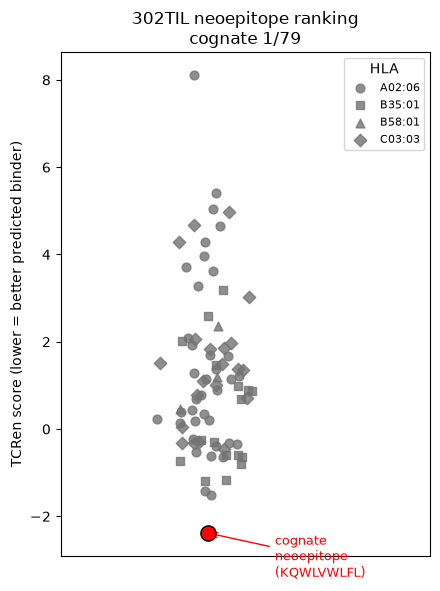

In [4]:
# Fig 2e: TCRen score of every candidate (shape = HLA), cognate neoepitope highlighted in red.
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 6))
rng = np.random.default_rng(0)
hlas = sorted(til['HLA'].unique().to_list())
markers = ['o', 's', '^', 'D', 'v', 'P', 'X']
for hla, mk in zip(hlas, markers):
    sub = til.filter((pl.col('HLA') == hla) & ~pl.col('real'))
    x = rng.normal(0, 0.06, sub.height)
    ax.scatter(x, sub['TCRen.score'], marker=mk, s=40, c='0.45', alpha=0.8, label=hla)
cog = til.filter(pl.col('real'))
ax.scatter([0], cog['TCRen.score'], marker='o', s=120, c='red', zorder=5, edgecolor='k')
ax.annotate(f'cognate\nneoepitope\n({COGNATE})', (0, cog['TCRen.score'][0]),
            xytext=(0.18, cog['TCRen.score'][0] - 1.0), color='red', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red'))
ax.set_xticks([]); ax.set_xlim(-0.4, 0.6)
ax.set_ylabel('TCRen score (lower = better predicted binder)')
ax.set_title(f'302TIL neoepitope ranking\ncognate {cog_rank}/{n}')
ax.legend(title='HLA', fontsize=8, loc='upper right')
plt.tight_layout()